<a href="https://colab.research.google.com/github/ongsoony8382/financial-data-programming/blob/main/%EC%87%BC%ED%95%91%EB%AA%B0_%EA%B3%A0%EA%B0%9D_%EA%B5%B0%EC%A7%91%ED%99%94(K_Means_Clustering).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**쇼핑몰 소비자 군집화 (K-Means Clustering)**


앞서 배운 '정답(생존여부, 보험료)'을 맞추는 것이 아니라, 정답 없이 데이터끼리 비슷한 것끼리 묶어주는 '비지도 학습' 예제

# 1. 데이터 로드 및 전처리

소비자의 '연간 소득(Annual Income)'과 '지출 점수(Spending Score)' 두 가지만 뽑아서 분석

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 쇼핑몰 소비자 데이터 (Kaggle 데이터셋의 Raw URL)
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
df_mall = pd.read_csv(url)

print(df_mall)

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [4]:
# 분석에 사용할 '연간소득'과 '지출점수'만 선택 (3, 4번 컬럼)
# iloc: 위치 기반 인덱싱

X = df_mall.iloc[:, [3, 4]].values
print("데이터 샘플 (소득, 지출점수):")
print(X[:5])

데이터 샘플 (소득, 지출점수):
[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


# 2. 자동으로 소비자 그룹 나누기 (K-Means)
사람의 눈으로 나누기 전에, K-Means 알고리즘이 소비자를 5개 그룹으로 자동 분류.

In [5]:
# 5개의 그룹으로 나누겠다고 설정
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)

# 학습 및 그룹 예측 (0~4번 그룹 번호 부여)
y_kmeans = kmeans.fit_predict(X)

# 결과 확인
print("각 소비자가 속한 그룹 번호:")
print(y_kmeans)

각 소비자가 속한 그룹 번호:
[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


# 3. 마케팅 타겟 시각화
- 소비자들이 어떻게 묶였는지 산점도로 확인
- 그래프를 이용하여 마케팅 전략을 제안.

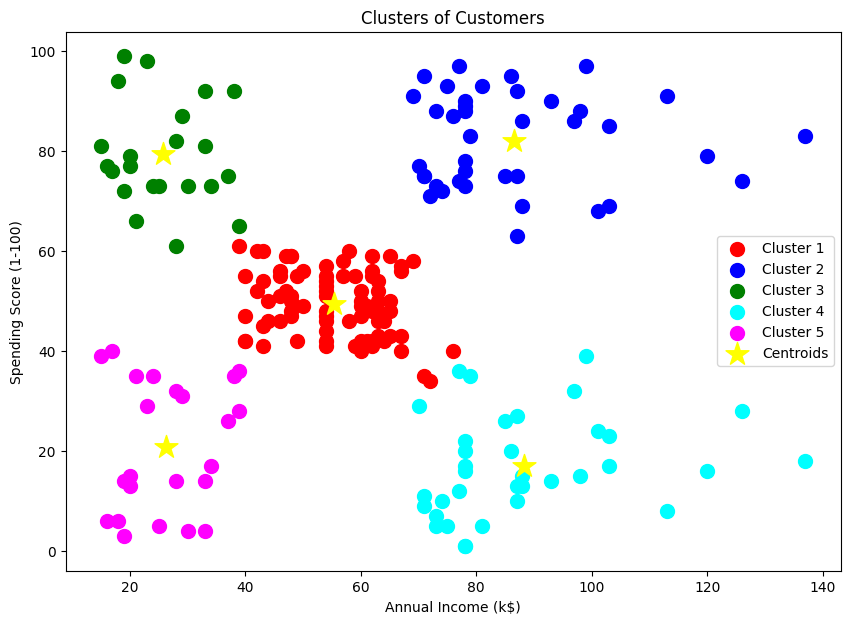

In [6]:
plt.figure(figsize=(10, 7))

# 5개 그룹별로 다른 색으로 점 찍기
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=100, c='cyan', label='Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=100, c='magenta', label='Cluster 5')

# 각 그룹의 중심점(Centroids) 표시
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids', marker='*')

plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()